In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from scipy.stats import zscore



# path to folder
path = ("data/melbourne-housing-market")

# Load 
df = pd.read_csv(
    f"{path}/Melbourne_housing_FULL.csv",
)

print(df.head())
print("SHAPE:", df.shape)
print("\nCOLUMNS:\n", df.columns.tolist())


       Suburb             Address  Rooms Type      Price Method SellerG  \
0  Abbotsford       68 Studley St      2    h        NaN     SS  Jellis   
1  Abbotsford        85 Turner St      2    h  1480000.0      S  Biggin   
2  Abbotsford     25 Bloomburg St      2    h  1035000.0      S  Biggin   
3  Abbotsford  18/659 Victoria St      3    u        NaN     VB  Rounds   
4  Abbotsford        5 Charles St      3    h  1465000.0     SP  Biggin   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/09/2016       2.5    3067.0  ...       1.0  1.0     126.0           NaN   
1  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
2  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
3  4/02/2016       2.5    3067.0  ...       2.0  1.0       0.0           NaN   
4  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   

   YearBuilt         CouncilArea Lattitude  Longtitude             R

In [276]:
# TASK 1 — AUDIT
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df.isnull().sum().values
})
missing_df["Missing Pct (%)"] = (missing_df["Missing Count"] / len(df)) * 100
missing_df = missing_df.sort_values("Missing Pct (%)", ascending=False)

print("\n=== MISSING VALUES ===")
print(missing_df)

# Drop target missing
df = df.dropna(subset=["Price"])

# Categorical cardinality
cat_cols = df.select_dtypes(include=['object', 'string']).columns
cardinality_df = pd.DataFrame({
    "Column": cat_cols,
    "Unique Values": [df[col].nunique() for col in cat_cols]
}).sort_values("Unique Values", ascending=False)

print("\n=== CARDINALITY ===")
print(cardinality_df)

# Baseline model
baseline_cols = ["Rooms", "Landsize", "BuildingArea", "Price"]
df_base = df[baseline_cols].dropna()

X_base = df_base[["Rooms", "Landsize", "BuildingArea"]]
y_base = df_base["Price"]

model = LinearRegression()
scores_base = cross_val_score(model, X_base, y_base, cv=5, scoring='r2')

print("\n=== BASELINE ===")
print("Mean:", scores_base.mean())
print("Std :", scores_base.std())



=== MISSING VALUES ===
           Column  Missing Count  Missing Pct (%)
14   BuildingArea          21115        60.576068
15      YearBuilt          19306        55.386293
13       Landsize          11810        33.881286
12            Car           8728        25.039447
11       Bathroom           8226        23.599277
10       Bedroom2           8217        23.573457
17      Lattitude           7976        22.882061
18     Longtitude           7976        22.882061
4           Price           7610        21.832057
19     Regionname              3         0.008607
16    CouncilArea              3         0.008607
20  Propertycount              3         0.008607
8        Distance              1         0.002869
9        Postcode              1         0.002869
2           Rooms              0         0.000000
1         Address              0         0.000000
0          Suburb              0         0.000000
3            Type              0         0.000000
6         SellerG         

In [277]:
# TASK 2 — MISSING HANDLING 

df_clean = df.copy()

missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df_clean.isnull().sum().values
})
missing_df["Missing Pct (%)"] = (missing_df["Missing Count"] / len(df_clean)) * 100
missing_df = missing_df.sort_values("Missing Pct (%)", ascending=False)

print("\n=== MISSING VALUES ===")
print(missing_df)

num_cols = df_clean.select_dtypes(include=np.number).columns
missing_pct = df_clean[num_cols].isnull().mean() * 100

cols_le_20 = missing_pct[missing_pct >= 20].index
cols_gt_20 = missing_pct[missing_pct < 20].index

for col in cols_le_20:
    if df_clean[col].isnull().sum() > 0:
        if abs(df_clean[col].skew()) > 1:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("\nRemaining Missing:", df_clean.isnull().sum().sum())


=== MISSING VALUES ===
           Column  Missing Count  Missing Pct (%)
14   BuildingArea          16591        60.891107
15      YearBuilt          15163        55.650163
13       Landsize           9265        34.003744
12            Car           6824        25.044959
11       Bathroom           6447        23.661321
10       Bedroom2           6441        23.639300
17      Lattitude           6254        22.952986
18     Longtitude           6254        22.952986
19     Regionname              3         0.011010
20  Propertycount              3         0.011010
16    CouncilArea              3         0.011010
9        Postcode              1         0.003670
8        Distance              1         0.003670
4           Price              0         0.000000
3            Type              0         0.000000
2           Rooms              0         0.000000
1         Address              0         0.000000
0          Suburb              0         0.000000
6         SellerG         

In [278]:

# ================================
# TASK 3 — ENCODING
# ================================

# Suburb - Frequency
freq = df_clean["Suburb"].value_counts(normalize=True)
df_clean["Suburb_freq"] = df_clean["Suburb"].map(freq)
df_clean.drop(columns=["Suburb"], inplace=True)

# SellerG - Target Encoding
target_mean = df_clean.groupby("SellerG")["Price"].mean()
df_clean["SellerG_encoded"] = df_clean["SellerG"].map(target_mean)
df_clean.drop(columns=["SellerG"], inplace=True)

# Drop Address
if "Address" in df_clean.columns:
    df_clean.drop(columns=["Address"], inplace=True)

# One-hot low cardinality
cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns
low_card_cols = [col for col in cat_cols if df_clean[col].nunique() < 15]

df_clean = pd.get_dummies(df_clean, columns=low_card_cols, drop_first=True)


In [279]:
df_model = df_clean.select_dtypes(include=np.number)
df_model.dropna(inplace = True)

X_model = df_model.drop(columns=["Price"])
y_model = df_model["Price"]

scores_model = cross_val_score(model, X_model, y_model, cv=5, scoring='r2', error_score = "raise")

print("\n=== MODEL ===")
print("Mean:", scores_model.mean())
print("Std :", scores_model.std())


=== MODEL ===
Mean: 0.5071348400222966
Std : 0.06534603401817907


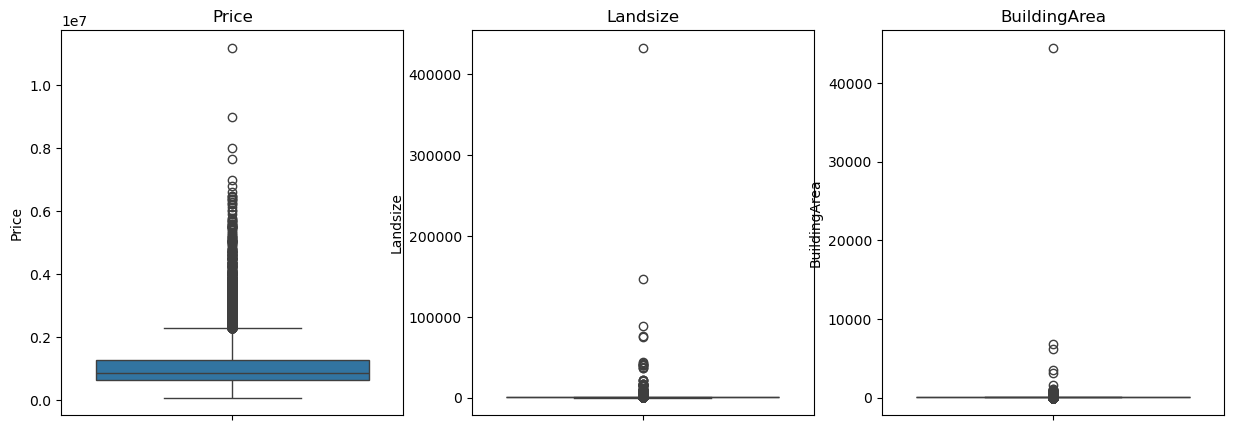


Outliers Price: 1278
Outliers Landsize: 24135


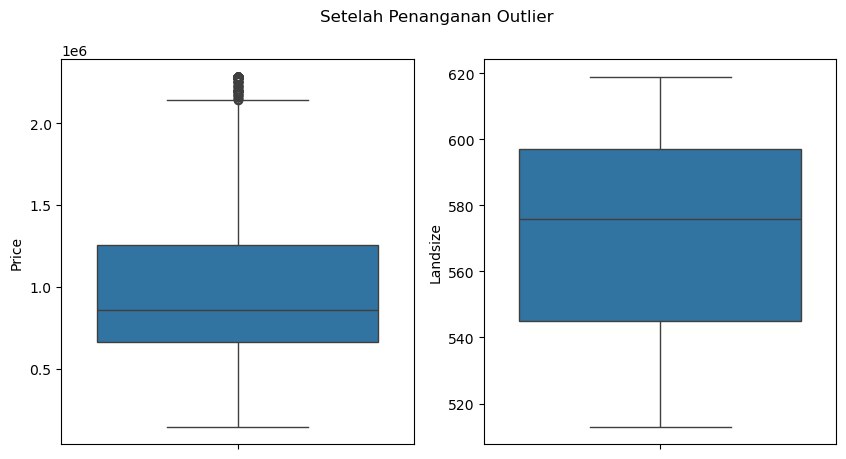

In [280]:

# ================================
# TASK 4 — OUTLIERS
# ================================

# Boxplot before
plt.figure(figsize=(15,5))
plt.subplot(1,3,1); sns.boxplot(y=df_clean["Price"]); plt.title("Price")
plt.subplot(1,3,2); sns.boxplot(y=df_clean["Landsize"]); plt.title("Landsize")
plt.subplot(1,3,3); sns.boxplot(y=df_clean["BuildingArea"]); plt.title("BuildingArea")
plt.show()

# IQR Price
Q1 = df_clean["Price"].quantile(0.25)
Q3 = df_clean["Price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

out_price = ((df_clean["Price"] < lower) | (df_clean["Price"] > upper)).sum()
print("\nOutliers Price:", out_price)

# Capping
df_clean["Price"] = np.clip(df_clean["Price"], lower, upper)

# Z-score Landsize
z_scores = np.abs(zscore(df_clean["Landsize"]))

out_land = np.sum(z_scores > 0.0176)
print("Outliers Landsize:", out_land)

df_clean = df_clean[z_scores <= 0.0176]

# Boxplot after
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); sns.boxplot(y=df_clean["Price"])
plt.subplot(1,2,2); sns.boxplot(y=df_clean["Landsize"])
plt.suptitle("Setelah Penanganan Outlier")
plt.show()


In [281]:

# ================================
# TASK 5 — FINAL MODEL
# ================================

df_final = df_clean.select_dtypes(include=np.number)

X_final = df_final.drop(columns=["Price"])
y_final = df_final["Price"]

scores_final = cross_val_score(model, X_final, y_final, cv=5, scoring='r2')

print("\n=== FINAL MODEL ===")
print("Mean:", scores_final.mean())
print("Std :", scores_final.std())


=== FINAL MODEL ===
Mean: 0.6744477460622686
Std : 0.02673384484846731


In [282]:
scores_base

array([ 0.30899593,  0.27995765,  0.22020667, -1.30637836,  0.077647  ])